# EfficientNet-B3 Binar — versiune corectată

**Ce s-a schimbat față de varianta ta și de ce:**

1. **Antrenare în două faze** (`FREEZE_BACKBONE_EPOCHS = 3`). În faza 1 backbone-ul e înghețat și se antrenează doar capul nou, cu LR mare (`1e-3`). În faza 2 se dezgheață tot, cu LR diferențiat: backbone `1e-4`, cap `3e-4`. Asta rezolvă cauza principală a platoului — capul random nu mai strică feature-urile ImageNet, iar `1e-5` uniform de dinainte era prea mic ca să învețe capul.
2. **Augmentare activată** (flip, rotație, color jitter) — era complet comentată.
3. **`num_workers=0`** — propriul tău comentariu avertiza că pe Windows `num_workers>0` îngheață la epoca 2, dar codul folosea `8`. Acum e consecvent.
4. **AUC raportat și monitorizat** — early stopping și checkpoint pe AUC de validare (metrică potrivită pentru context medical), nu doar accuracy.
5. **Prag de decizie ales pe validare** (Youden's J) și aplicat consecvent pe test — înainte aveai `0.5` la validare și `0.3` la test, ceea ce nu e reproductibil.
6. **Etichete forțate la `float`** în buclă — defensiv, ca `BCEWithLogitsLoss` să nu crape indiferent de ce returnează `binary_dataset.py`.
7. **Celulă opțională de sanity-check** (overfit pe 100 de imagini) ca să verifici că pipeline-ul învață înainte să aștepți ore.

> **Notă despre Ben Graham:** datele tale sunt deja în `processed_by_me/...`, deci preprocesarea de fundus e lăsată **dezactivată** (`USE_BEN_GRAHAM = False`). Dacă platoul persistă după aceste schimbări, pune-o pe `True` și verifică mai întâi pe câteva imagini cum arată rezultatul (nu o aplica orbește peste date deja procesate).

In [1]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from torch.utils.data import DataLoader, Subset
from tqdm import tqdm
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Importam DOAR clasa de Dataset din fisierul nostru extern
from binary_dataset import BinaryRetinopathyDataset

print("=== ÎNCĂRCARE DATE ȘI DATALOADERS ===")

DATA_DIR = r'B:\Projects\Disertatie\Diabetic-Retinopathy-Classifier\datasets\processed_by_me\eyepacs\eyepacs_binar'
IMG_SIZE = 300          # rezolutia nativa a EfficientNet-B3
BATCH_SIZE = 32         # scade la 16/8 daca iei CUDA Out of Memory
USE_BEN_GRAHAM = False  # vezi nota din primul cell inainte sa activezi


# --- Preprocesare optionala specifica de fundus (Ben Graham, EyePACS 2015) ---
class BenGrahamPreprocess:
    """Crop circular + scaderea mediei locale de culoare (Gaussian blur).
    Foloseste-o DOAR daca imaginile nu sunt deja preprocesate astfel."""
    def __init__(self, sigma_scale=10, crop_tol=7):
        self.sigma_scale = sigma_scale
        self.crop_tol = crop_tol

    def _crop_to_circle(self, img):
        import cv2
        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        mask = gray > self.crop_tol
        if mask.sum() == 0:
            return img
        coords = np.argwhere(mask)
        y0, x0 = coords.min(axis=0)
        y1, x1 = coords.max(axis=0) + 1
        return img[y0:y1, x0:x1]

    def __call__(self, img):
        import cv2
        from PIL import Image
        arr = np.array(img.convert("RGB"))
        arr = self._crop_to_circle(arr)
        s = max(arr.shape[0], arr.shape[1]) / self.sigma_scale
        blurred = cv2.GaussianBlur(arr, (0, 0), s)
        arr = cv2.addWeighted(arr, 4, blurred, -4, 128)
        return Image.fromarray(np.clip(arr, 0, 255).astype(np.uint8))


_pre = [BenGrahamPreprocess()] if USE_BEN_GRAHAM else []
_norm = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

# 1. Transformari - AUGMENTAREA E ACUM ACTIVA pe train
train_transform = transforms.Compose(_pre + [
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    _norm,
])

test_transform = transforms.Compose(_pre + [
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    _norm,
])

# 2. Dataseturi
train_ds = BinaryRetinopathyDataset(os.path.join(DATA_DIR, 'train'), transform=train_transform)
val_ds   = BinaryRetinopathyDataset(os.path.join(DATA_DIR, 'val'),   transform=test_transform)
test_ds  = BinaryRetinopathyDataset(os.path.join(DATA_DIR, 'test'),  transform=test_transform)

# 3. DataLoadere - num_workers=0 pe Windows (vezi avertismentul tau despre inghetare)
NUM_WORKERS = 7
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print("DataLoaderele au fost create cu succes!")
print(f"Numar de batch-uri pe antrenament: {len(train_loader)}")
print(f"Ben Graham: {'ACTIV' if USE_BEN_GRAHAM else 'dezactivat'}")


=== ÎNCĂRCARE DATE ȘI DATALOADERS ===
DataLoaderele au fost create cu succes!
Numar de batch-uri pe antrenament: 3021
Ben Graham: dezactivat


## Model + configurație în două faze

Construim o singură dată modelul. Optimizatorul îl construim pe faze: în faza 1 doar capul, în faza 2 două grupuri de parametri cu LR diferit.

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Antrenam pe: {device}")

# --- Hiperparametri ---
HEAD_LR_PHASE1     = 1e-3   # LR mare pentru capul random, cu backbone inghetat
BACKBONE_LR_PHASE2 = 1e-4   # LR mic pentru backbone-ul pre-antrenat
HEAD_LR_PHASE2     = 3e-4   # capul ramane putin mai "rapid" decat backbone-ul
WEIGHT_DECAY       = 1e-4
DROPOUT            = 0.40
FREEZE_BACKBONE_EPOCHS  = 3   # cate epoci tinem backbone-ul inghetat (faza 1)
EARLY_STOPPING_PATIENCE = 5
USE_POS_WEIGHT     = False     # setul binarizat e deja ~50/50

# --- EfficientNet-B3 pre-antrenat ---
model = models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.IMAGENET1K_V1)
num_features = model.classifier[1].in_features
model.classifier[1] = nn.Sequential(
    nn.Dropout(p=DROPOUT),
    nn.Linear(num_features, 1)
)
model = model.to(device)

# Verificam distributia claselor
num_sanatosi = len(os.listdir(os.path.join(DATA_DIR, 'train', 'sanatos')))
num_bolnavi  = len(os.listdir(os.path.join(DATA_DIR, 'train', 'bolnav')))
print(f"Clase: sanatos={num_sanatosi}, bolnav={num_bolnavi}")

if USE_POS_WEIGHT:
    pos_weight = torch.tensor([num_sanatosi / max(num_bolnavi, 1)], dtype=torch.float32, device=device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    print(f"pos_weight activ: {pos_weight.item():.4f}")
else:
    criterion = nn.BCEWithLogitsLoss()
    print("pos_weight dezactivat (set echilibrat).")


# --- Helpers pentru inghet/dezghet si construirea optimizatorului pe faze ---
def set_backbone_trainable(m, trainable):
    for name, p in m.named_parameters():
        if not name.startswith("classifier"):
            p.requires_grad = trainable

def split_params(m):
    head = [p for n, p in m.named_parameters() if n.startswith("classifier")]
    backbone = [p for n, p in m.named_parameters() if not n.startswith("classifier")]
    return head, backbone

def build_optimizer_phase1(m):
    set_backbone_trainable(m, False)  # backbone inghetat
    head, _ = split_params(m)
    opt = optim.AdamW(head, lr=HEAD_LR_PHASE1, weight_decay=WEIGHT_DECAY)
    sch = optim.lr_scheduler.ReduceLROnPlateau(opt, mode='max', factor=0.5, patience=2)
    return opt, sch

def build_optimizer_phase2(m):
    set_backbone_trainable(m, True)   # tot dezghetat
    head, backbone = split_params(m)
    opt = optim.AdamW([
        {"params": backbone, "lr": BACKBONE_LR_PHASE2},
        {"params": head,     "lr": HEAD_LR_PHASE2},
    ], weight_decay=WEIGHT_DECAY)
    sch = optim.lr_scheduler.ReduceLROnPlateau(opt, mode='max', factor=0.5, patience=2)
    return opt, sch

scaler = torch.amp.GradScaler('cuda')
print("Model si configuratie gata. Faza 1 (backbone inghetat) incepe la antrenare.")


Antrenam pe: cuda
Clase: sanatos=48332, bolnav=48332
pos_weight dezactivat (set echilibrat).
Model si configuratie gata. Faza 1 (backbone inghetat) incepe la antrenare.


## (Opțional) Sanity-check: poate modelul să suprainvețe 100 de imagini?

Rulează celula asta o singură dată ca diagnostic. Dacă în ~20 de epoci pe 100 de imagini **nu** ajunge aproape de 100% acuratețe pe train, problema e în date / preprocesare / etichete, nu în model — și nu are rost să antrenezi ore întregi. Sari peste ea pentru antrenarea reală.

In [3]:
RUN_SANITY = False  # pune True ca sa rulezi diagnosticul

if RUN_SANITY:
    import copy
    small = Subset(train_ds, list(range(100)))
    small_loader = DataLoader(small, batch_size=16, shuffle=True, num_workers=0)
    m = copy.deepcopy(model)
    set_backbone_trainable(m, True)
    opt = optim.AdamW(m.parameters(), lr=1e-4, weight_decay=0)
    for ep in range(20):
        m.train(); preds, tgts = [], []
        for images, labels in small_loader:
            images = images.to(device); labels = labels.float().to(device)
            opt.zero_grad()
            with torch.amp.autocast('cuda'):
                out = m(images).squeeze(1)
                loss = criterion(out, labels)
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
            preds += ((torch.sigmoid(out) > 0.5).int().detach().cpu().numpy().tolist())
            tgts  += labels.int().cpu().numpy().tolist()
        acc = accuracy_score(tgts, preds)
        print(f"sanity epoca {ep+1}: train_acc={acc:.3f}")
    print("Daca acc ajunge ~1.0 -> pipeline OK. Daca ramane ~0.5 -> problema in date/etichete.")
else:
    print("Sanity-check dezactivat (RUN_SANITY=False).")


Sanity-check dezactivat (RUN_SANITY=False).


## Antrenare (două faze + early stopping pe AUC)

In [4]:
EPOCHS = 30
best_val_auc = -1.0
bad_epochs = 0

# Pornim in faza 1: backbone inghetat, doar capul
optimizer, scheduler = build_optimizer_phase1(model)
print("=== INCEPERE ANTRENARE - FAZA 1 (backbone inghetat) ===")

history = {"train_loss": [], "val_loss": [], "val_acc": [], "val_auc": []}

for epoch in range(EPOCHS):
    # Tranzitia la faza 2
    if epoch == FREEZE_BACKBONE_EPOCHS:
        optimizer, scheduler = build_optimizer_phase2(model)
        print("=== FAZA 2: backbone dezghetat, fine-tuning complet cu LR diferentiat ===")

    # ---- TRAIN ----
    model.train()
    train_loss = 0.0
    for images, labels in tqdm(train_loader, desc=f"Epoca {epoch+1}/{EPOCHS} [TRAIN]"):
        images = images.to(device)
        labels = labels.float().to(device)        # defensiv: BCEWithLogits cere float
        optimizer.zero_grad()
        with torch.amp.autocast('cuda'):
            outputs = model(images).squeeze(1)
            loss = criterion(outputs, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        train_loss += loss.item() * images.size(0)

    # ---- VAL ----
    model.eval()
    val_loss = 0.0
    val_probs, val_targets = [], []
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc=f"Epoca {epoch+1}/{EPOCHS} [VAL]"):
            images = images.to(device)
            labels = labels.float().to(device)
            outputs = model(images).squeeze(1)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            val_probs.extend(torch.sigmoid(outputs).cpu().numpy())
            val_targets.extend(labels.cpu().numpy())

    avg_train_loss = train_loss / len(train_ds)
    avg_val_loss   = val_loss / len(val_ds)
    val_preds = (np.array(val_probs) > 0.5).astype(int)
    val_acc = accuracy_score(val_targets, val_preds)
    try:
        val_auc = roc_auc_score(val_targets, val_probs)
    except ValueError:
        val_auc = float("nan")

    history["train_loss"].append(avg_train_loss)
    history["val_loss"].append(avg_val_loss)
    history["val_acc"].append(val_acc)
    history["val_auc"].append(val_auc)

    scheduler.step(val_auc)  # scheduler pe AUC (mode='max')

    print(f"Epoca {epoch+1}: T_Loss={avg_train_loss:.4f} | V_Loss={avg_val_loss:.4f} "
          f"| V_Acc={val_acc:.4f} | V_AUC={val_auc:.4f}")

    # Checkpoint + early stopping pe AUC
    if val_auc > best_val_auc + 1e-4:
        best_val_auc = val_auc
        bad_epochs = 0
        torch.save(model.state_dict(), 'efficientnet_b3_binar_best.pth')
        print(f"Model nou salvat! (Val AUC: {best_val_auc:.4f})")
    else:
        bad_epochs += 1
        print(f"Fara imbunatatire pe AUC: {bad_epochs}/{EARLY_STOPPING_PATIENCE}")
        if bad_epochs >= EARLY_STOPPING_PATIENCE:
            print("Early stopping.")
            break

print(f"Cel mai bun Val AUC: {best_val_auc:.4f}")


=== INCEPERE ANTRENARE - FAZA 1 (backbone inghetat) ===


Epoca 1/30 [VAL]: 100%|██████████| 416/416 [01:22<00:00,  5.02it/s]


Epoca 1: T_Loss=0.5762 | V_Loss=0.5255 | V_Acc=0.7750 | V_AUC=0.6484
Model nou salvat! (Val AUC: 0.6484)


Epoca 2/30 [VAL]: 100%|██████████| 416/416 [01:23<00:00,  5.00it/s]


Epoca 2: T_Loss=0.5618 | V_Loss=1.4678 | V_Acc=0.7784 | V_AUC=0.6532
Model nou salvat! (Val AUC: 0.6532)


...

Epoca 14: T_Loss=0.1800 | V_Loss=0.3556 | V_Acc=0.8779 | V_AUC=0.8507
Fara imbunatatire pe AUC: 3/5


Epoca 15/30 [VAL]: 100%|██████████| 416/416 [01:20<00:00,  5.14it/s]


Epoca 15: T_Loss=0.1600 | V_Loss=0.3605 | V_Acc=0.8784 | V_AUC=0.8509
Fara imbunatatire pe AUC: 4/5


Epoca 16/30 [VAL]: 100%|██████████| 416/416 [01:20<00:00,  5.17it/s]

Epoca 16: T_Loss=0.1507 | V_Loss=0.3673 | V_Acc=0.8789 | V_AUC=0.8536
Fara imbunatatire pe AUC: 5/5
Early stopping.
Cel mai bun Val AUC: 0.8602


## Evaluare pe test (prag ales pe validare)

Alegem pragul de decizie pe setul de **validare** (Youden's J = max(TPR − FPR)) și îl aplicăm pe test. Raportăm și varianta la pragul standard 0.5 pentru comparație.

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Înlocuiește celula de alegere a pragului cu:
from sklearn.metrics import f1_score
from sklearn.metrics import fbeta_score

# beta=2 → FN sunt de 2x mai grave decât FP (recomandat pentru screening medical)
# beta=1 → F1 clasic, egal
# beta=0.5 → FP sunt mai grave (nu recomandat pentru DR)

beta = 2.0
best_thr, best_fb = 0.5, 0.0

for t in np.linspace(0.01, 0.99, 200):
    preds = (np.array(val_probs) > t).astype(int)
    fb = fbeta_score(val_targets, preds, beta=beta, pos_label=1, zero_division=0)
    if fb > best_fb:
        best_fb = fb
        best_thr = t

print(f"Prag optim pe F{beta}: {best_thr:.3f} (F{beta}={best_fb:.3f})")

# 2. Probabilitati pe TEST
test_probs, test_targets = [], []
with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testare"):
        images = images.to(device)
        outputs = model(images).squeeze(1)
        test_probs.extend(torch.sigmoid(outputs).cpu().numpy())
        test_targets.extend(labels.numpy())

test_probs = np.array(test_probs)
test_auc = roc_auc_score(test_targets, test_probs)
print(f"\nTest AUC: {test_auc:.4f}")

for label, t in [("prag 0.5", 0.5), (f"prag {best_thr:.3f} (din val)", best_thr)]:
    preds = (test_probs > t).astype(int)
    print(f"\nRAPORT - {label}:")
    print(classification_report(test_targets, preds, target_names=['Sanatos (0)', 'Bolnav (1)']))

# 3. Matricea de confuzie la pragul ales pe validare
preds = (test_probs > best_thr).astype(int)
cm = confusion_matrix(test_targets, preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Sanatos (0)', 'Bolnav (1)'],
            yticklabels=['Sanatos (0)', 'Bolnav (1)'],
            annot_kws={"size": 16})
plt.title('Matrice de Confuzie - EfficientNet-B3 (Binar)', fontsize=16, fontweight='bold', pad=15)
plt.ylabel('Eticheta Adevarata', fontsize=14, fontweight='bold')
plt.xlabel('Eticheta Prezisa', fontsize=14, fontweight='bold')
plt.xticks(fontsize=12); plt.yticks(fontsize=12, rotation=0)
plt.savefig('matrice_confuzie_binar.png', dpi=300, bbox_inches='tight')
plt.show()


KeyError: 'avg_train_loss'

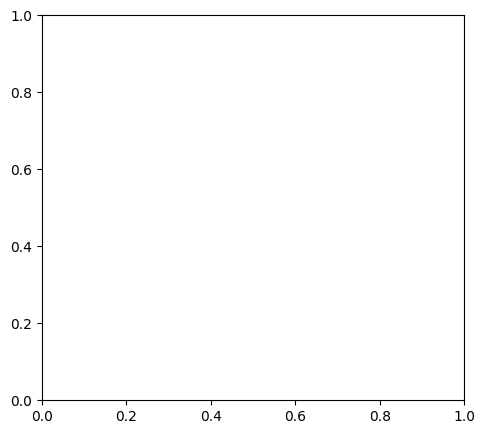

In [25]:
# Afiseaza grafice


# EfficientNet-B3 Multiclasă (grade 1-4) — 3 formulări comparabile

Acelaşi backbone, aceeaşi antrenare în două faze, aceleaşi date. Schimbi un singur comutator `MODE` şi obţii numere QWK comparabile între trei formulări ale problemei:

| `MODE` | Cap | Loss | De ce |
|---|---|---|---|
| `crossentropy` | 4 ieşiri (softmax) | CrossEntropy + **label smoothing 0.1** | baseline-ul tău actual, dar tratează clasele ca *nominale* (eroarea 1↔4 = eroarea 1↔2) |
| `regression` | 1 ieşire | SmoothL1 pe gradul continuu, apoi **rounder optimizat pe validare** | aliniat cu QWK; abordarea câştigătoare clasică pe EyePACS |
| `ordinal` | 3 ieşiri (CORAL) | CORAL loss (praguri cumulative monotone) | modelează explicit ordinea gradelor |

**Recomandare experimente pentru teză:** rulează toate trei cu acelaşi seed şi raportează QWK pe test într-un tabel. Povestea „am comparat formularea nominală vs. regresie vs. ordinală şi am ales-o pe cea cu QWK maxim" e exact tipul de contribuţie cerut.

> Etichetele interne sunt 0-3 (din `class_to_idx`: stadiul_1→0 … stadiul_4→3). QWK e identic indiferent de offset, deci nu trebuie să mapezi înapoi la 1-4 decât la afişare.

## Încărcare date și DataLoadere

In [6]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import models, transforms
from torch.utils.data import DataLoader, Subset
from tqdm import tqdm
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, cohen_kappa_score
import scipy.optimize as opt
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from pathlib import Path

# ================================================================
# CONFIGURARE
# ================================================================
DATA_DIR    = r'B:\Projects\Disertatie\Diabetic-Retinopathy-Classifier\datasets\processed_by_me\eyepacs\eyepacs_1_4'
IMG_SIZE    = 300
BATCH_SIZE  = 32
NUM_CLASSES = 4
CLASS_NAMES = ['Stadiul 1', 'Stadiul 2', 'Stadiul 3', 'Stadiul 4']
NUM_WORKERS = 8   # pe Windows: daca ingheata la granita dintre epoci, pune 0

_norm = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ToTensor(),
    _norm,
])
test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    _norm,
])

LOCAL_DIR = Path(r'B:\Projects\Disertatie\Diabetic-Retinopathy-Classifier\Notebooks\Main\Local')
if str(LOCAL_DIR) not in sys.path:
    sys.path.insert(0, str(LOCAL_DIR))
from dataset_1_4 import MultiClassRetinopathyDataset

train_ds = MultiClassRetinopathyDataset(os.path.join(DATA_DIR, 'train'), transform=train_transform)
val_ds   = MultiClassRetinopathyDataset(os.path.join(DATA_DIR, 'val'),   transform=test_transform)
test_ds  = MultiClassRetinopathyDataset(os.path.join(DATA_DIR, 'test'),  transform=test_transform)

loader_kwargs = {'num_workers': NUM_WORKERS, 'pin_memory': torch.cuda.is_available()}
if NUM_WORKERS > 0:
    loader_kwargs['prefetch_factor'] = 1

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  **loader_kwargs)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, **loader_kwargs)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, **loader_kwargs)

print("=== STATISTICI DATASET ===")
print(f"Mapare clase: {train_ds.class_to_idx}")
for split_name, ds in [("TRAIN", train_ds), ("VAL", val_ds), ("TEST", test_ds)]:
    targets = np.array(ds.targets)
    print(f"{split_name} ({len(ds)}): " + ", ".join(f"{c}={(targets==i).sum()}" for i,c in enumerate(CLASS_NAMES)))
print(f"Batch-uri train: {len(train_loader)}")


=== STATISTICI DATASET ===
Mapare clase: {'stadiul_1': 0, 'stadiul_2': 1, 'stadiul_3': 2, 'stadiul_4': 3}
TRAIN (40000): Stadiul 1=10000, Stadiul 2=10000, Stadiul 3=10000, Stadiul 4=10000
VAL (3503): Stadiul 1=930, Stadiul 2=1973, Stadiul 3=313, Stadiul 4=287
TEST (3504): Stadiul 1=931, Stadiul 2=1973, Stadiul 3=313, Stadiul 4=287
Batch-uri train: 1250


## Comutator MODE + capete, loss-uri și decodare

Aici se află toată logica specifică fiecărei formulări. Schimbă `MODE` și re-rulează de aici în jos.

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Antrenam pe: {device}")

# ================================================================
# >>> SCHIMBA DOAR ASTA <<<
MODE = "regression"   # "crossentropy" | "regression" | "ordinal"
# ================================================================

HEAD_LR_PHASE1          = 1e-3
BACKBONE_LR_PHASE2      = 1e-4
HEAD_LR_PHASE2          = 3e-4
WEIGHT_DECAY            = 1e-4
DROPOUT                 = 0.40
FREEZE_BACKBONE_EPOCHS  = 3
TOTAL_EPOCHS            = 30
EARLY_STOPPING_PATIENCE = 6
LABEL_SMOOTHING         = 0.10   # folosit doar la crossentropy
SEED                    = 42

torch.manual_seed(SEED); np.random.seed(SEED)

# ---------------- CORAL (mod ordinal) ----------------
class CoralLayer(nn.Module):
    """Un singur set de ponderi + K-1 bias-uri independente => praguri monotone."""
    def __init__(self, in_features, num_classes):
        super().__init__()
        self.fc = nn.Linear(in_features, 1, bias=False)
        self.bias = nn.Parameter(torch.zeros(num_classes - 1).float())
    def forward(self, x):
        return self.fc(x) + self.bias            # [B, K-1]

def labels_to_levels(labels, num_classes):
    rng = torch.arange(num_classes - 1, device=labels.device).unsqueeze(0)
    return (labels.unsqueeze(1) > rng).float()    # ex: label 2 -> [1,1,0]

def coral_loss(logits, levels):
    return (-torch.sum(F.logsigmoid(logits) * levels
            + (F.logsigmoid(logits) - logits) * (1 - levels), dim=1)).mean()

def coral_decode(logits):
    return (torch.sigmoid(logits) > 0.5).sum(dim=1)   # numara cate praguri sunt depasite

# ---------------- Construire model in functie de MODE ----------------
def build_model(mode):
    m = models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.IMAGENET1K_V1)
    nf = m.classifier[1].in_features
    if mode == "crossentropy":
        m.classifier[1] = nn.Sequential(nn.Dropout(DROPOUT), nn.Linear(nf, NUM_CLASSES))
    elif mode == "regression":
        m.classifier[1] = nn.Sequential(nn.Dropout(DROPOUT), nn.Linear(nf, 1))
    elif mode == "ordinal":
        m.classifier = nn.Sequential(nn.Dropout(DROPOUT), CoralLayer(nf, NUM_CLASSES))
    else:
        raise ValueError(f"MODE necunoscut: {mode}")
    return m.to(device)

model = build_model(MODE)
ce_criterion  = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
reg_criterion = nn.SmoothL1Loss()

def compute_loss(out, labels):
    if MODE == "crossentropy":
        return ce_criterion(out, labels)
    if MODE == "regression":
        return reg_criterion(out.squeeze(1), labels.float())
    if MODE == "ordinal":
        return coral_loss(out, labels_to_levels(labels, NUM_CLASSES))

def decode(out):
    """Predictii intregi 0..K-1 pentru monitorizare (regresie: rotunjire naiva)."""
    if MODE == "crossentropy":
        return out.argmax(1)
    if MODE == "regression":
        return out.squeeze(1).round().clamp(0, NUM_CLASSES - 1).long()
    if MODE == "ordinal":
        return coral_decode(out)

def raw_scores(out):
    """Iesirea continua pentru regresie (necesara la rounder-ul optimizat)."""
    return out.squeeze(1) if MODE == "regression" else None

# ---------------- Rounder optimizat pe validare (doar regresie) ----------------
class OptimizedRounder:
    """Alege K-1 praguri care maximizeaza QWK pe validare (Nelder-Mead)."""
    def __init__(self, n_classes): self.n_classes = n_classes; self.coef_ = None
    def _classify(self, X, coef):
        return np.clip(np.digitize(X, np.sort(coef)), 0, self.n_classes - 1)
    def _neg_qwk(self, coef, X, y):
        return -cohen_kappa_score(y, self._classify(X, coef), weights='quadratic')
    def fit(self, X, y):
        init = np.arange(self.n_classes - 1) + 0.5
        r = opt.minimize(self._neg_qwk, init, args=(X, y), method='Nelder-Mead')
        self.coef_ = np.sort(r.x)
    def predict(self, X):
        return self._classify(X, self.coef_)

# ---------------- Freeze/unfreeze + optimizatoare pe faze ----------------
def set_backbone_trainable(m, trainable):
    for name, p in m.named_parameters():
        if not name.startswith("classifier"):
            p.requires_grad = trainable

def split_params(m):
    head     = [p for n, p in m.named_parameters() if n.startswith("classifier")]
    backbone = [p for n, p in m.named_parameters() if not n.startswith("classifier")]
    return head, backbone

def build_optimizer_phase1(m):
    set_backbone_trainable(m, False)
    head, _ = split_params(m)
    o = optim.AdamW(head, lr=HEAD_LR_PHASE1, weight_decay=WEIGHT_DECAY)
    s = optim.lr_scheduler.ReduceLROnPlateau(o, mode='max', factor=0.5, patience=2)
    return o, s

def build_optimizer_phase2(m):
    set_backbone_trainable(m, True)
    head, backbone = split_params(m)
    o = optim.AdamW([{"params": backbone, "lr": BACKBONE_LR_PHASE2},
                     {"params": head,     "lr": HEAD_LR_PHASE2}], weight_decay=WEIGHT_DECAY)
    s = optim.lr_scheduler.ReduceLROnPlateau(o, mode='max', factor=0.5, patience=2)
    return o, s

scaler = torch.amp.GradScaler('cuda')
CKPT = f'efficientnet_b3_multiclass_{MODE}.pth'
print(f"MODE = {MODE} | checkpoint -> {CKPT}")


Antrenam pe: cuda
MODE = regression | checkpoint -> efficientnet_b3_multiclass_regression.pth


## (Opțional) Sanity-check: poate modelul memora 100 imagini?

In [8]:
RUN_SANITY = True

if RUN_SANITY:
    import copy
    small = Subset(train_ds, list(range(100)))
    small_loader = DataLoader(small, batch_size=16, shuffle=True, num_workers=0)
    m = copy.deepcopy(model); set_backbone_trainable(m, True)
    o = optim.AdamW(m.parameters(), lr=1e-4, weight_decay=0)
    for ep in range(20):
        m.train(); preds, tgts = [], []
        for images, labels in small_loader:
            images, labels = images.to(device), labels.to(device)
            o.zero_grad()
            with torch.amp.autocast('cuda', enabled=(device.type=='cuda')):
                out = m(images); loss = compute_loss(out, labels)
            scaler.scale(loss).backward(); scaler.step(o); scaler.update()
            preds += decode(out).detach().cpu().tolist(); tgts += labels.cpu().tolist()
        print(f"sanity epoca {ep+1}: train_acc={accuracy_score(tgts, preds):.3f}")
    print("~1.0 -> pipeline OK | ~0.25 -> problema in date/etichete")
else:
    print("Sanity-check dezactivat.")


sanity epoca 1: train_acc=0.990
sanity epoca 2: train_acc=1.000
sanity epoca 3: train_acc=0.980
sanity epoca 4: train_acc=1.000
sanity epoca 5: train_acc=1.000
sanity epoca 6: train_acc=1.000
sanity epoca 7: train_acc=1.000
sanity epoca 8: train_acc=1.000
sanity epoca 9: train_acc=1.000
sanity epoca 10: train_acc=1.000
sanity epoca 11: train_acc=1.000
sanity epoca 12: train_acc=1.000
sanity epoca 13: train_acc=1.000
sanity epoca 14: train_acc=1.000
sanity epoca 15: train_acc=1.000
sanity epoca 16: train_acc=1.000
sanity epoca 17: train_acc=1.000
sanity epoca 18: train_acc=1.000
sanity epoca 19: train_acc=1.000
sanity epoca 20: train_acc=1.000
~1.0 -> pipeline OK | ~0.25 -> problema in date/etichete


## Antrenare (două faze + early stopping pe QWK)

In [9]:
optimizer, scheduler = build_optimizer_phase1(model)
best_val_qwk = -1.0
epochs_no_improve = 0
history = {'t_loss': [], 'v_loss': [], 'v_acc': [], 'v_qwk': []}

print(f"=== ANTRENARE [{MODE}] - FAZA 1 (backbone inghetat) ===")

for epoch in range(TOTAL_EPOCHS):
    if epoch == FREEZE_BACKBONE_EPOCHS:
        optimizer, scheduler = build_optimizer_phase2(model)
        print("=== FAZA 2: backbone dezghetat, fine-tuning complet ===")

    # ---- TRAIN ----
    model.train(); train_loss = 0.0
    for images, labels in tqdm(train_loader, desc=f"Epoca {epoch+1}/{TOTAL_EPOCHS} [TRAIN]"):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast('cuda', enabled=(device.type=='cuda')):
            out = model(images); loss = compute_loss(out, labels)
        scaler.scale(loss).backward(); scaler.step(optimizer); scaler.update()
        train_loss += loss.item() * images.size(0)

    # ---- VAL ----
    model.eval(); val_loss = 0.0; val_preds, val_targets = [], []
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc=f"Epoca {epoch+1}/{TOTAL_EPOCHS} [VAL]"):
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            with torch.amp.autocast('cuda', enabled=(device.type=='cuda')):
                out = model(images); loss = compute_loss(out, labels)
            val_loss += loss.item() * images.size(0)
            val_preds.extend(decode(out).detach().cpu().tolist())
            val_targets.extend(labels.detach().cpu().tolist())

    avg_train_loss = train_loss / len(train_ds)
    avg_val_loss   = val_loss / len(val_ds)
    val_acc = accuracy_score(val_targets, val_preds)
    val_qwk = cohen_kappa_score(val_targets, val_preds, weights='quadratic')
    for k, v in zip(history, [avg_train_loss, avg_val_loss, val_acc, val_qwk]):
        history[k].append(v)
    scheduler.step(val_qwk)

    print(f"Epoca {epoch+1}: T_Loss={avg_train_loss:.4f} | V_Loss={avg_val_loss:.4f} "
          f"| V_Acc={val_acc:.4f} | V_QWK={val_qwk:.4f}")

    if val_qwk > best_val_qwk + 1e-4:
        best_val_qwk = val_qwk; epochs_no_improve = 0
        torch.save(model.state_dict(), CKPT)
        print(f"Model nou salvat! (Val QWK: {best_val_qwk:.4f})")
    else:
        epochs_no_improve += 1
        print(f"Fara imbunatatire pe QWK: {epochs_no_improve}/{EARLY_STOPPING_PATIENCE}")
        if epochs_no_improve >= EARLY_STOPPING_PATIENCE:
            print("Early stopping."); break

print(f"Cel mai bun Val QWK [{MODE}]: {best_val_qwk:.4f}")


=== ANTRENARE [regression] - FAZA 1 (backbone inghetat) ===


Epoca 1/30 [VAL]: 100%|██████████| 110/110 [00:42<00:00,  2.62it/s]


Epoca 1: T_Loss=0.4118 | V_Loss=0.2625 | V_Acc=0.5024 | V_QWK=0.4252
Model nou salvat! (Val QWK: 0.4252)


Epoca 2/30 [VAL]: 100%|██████████| 110/110 [00:36<00:00,  3.02it/s]


Epoca 2: T_Loss=0.3931 | V_Loss=0.2597 | V_Acc=0.5076 | V_QWK=0.4246
Fara imbunatatire pe QWK: 1/6


...

Epoca 14: T_Loss=0.0570 | V_Loss=0.1611 | V_Acc=0.6549 | V_QWK=0.6468
Fara imbunatatire pe QWK: 4/6


Epoca 15/30 [VAL]: 100%|██████████| 110/110 [00:38<00:00,  2.83it/s]


Epoca 15: T_Loss=0.0544 | V_Loss=0.1598 | V_Acc=0.6566 | V_QWK=0.6422
Fara imbunatatire pe QWK: 5/6


Epoca 16/30 [VAL]: 100%|██████████| 110/110 [00:36<00:00,  3.01it/s]

Epoca 16: T_Loss=0.0522 | V_Loss=0.1663 | V_Acc=0.6512 | V_QWK=0.6438
Fara imbunatatire pe QWK: 6/6
Early stopping.
Cel mai bun Val QWK [regression]: 0.6579


## Curbe de antrenare

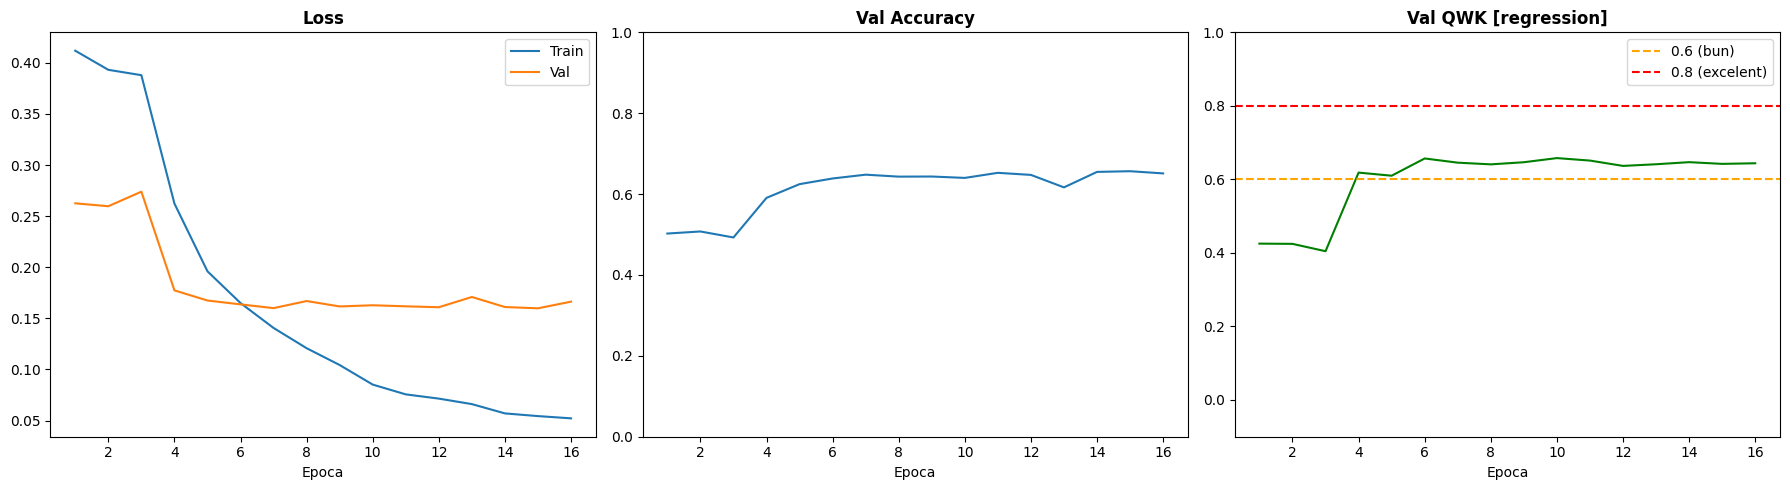

In [10]:
xs = range(1, len(history['t_loss']) + 1)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(xs, history['t_loss'], label='Train'); axes[0].plot(xs, history['v_loss'], label='Val')
axes[0].set_title('Loss', fontweight='bold'); axes[0].legend(); axes[0].set_xlabel('Epoca')
axes[1].plot(xs, history['v_acc']); axes[1].set_title('Val Accuracy', fontweight='bold')
axes[1].set_xlabel('Epoca'); axes[1].set_ylim(0, 1)
axes[2].plot(xs, history['v_qwk'], color='green'); axes[2].set_title(f'Val QWK [{MODE}]', fontweight='bold')
axes[2].set_xlabel('Epoca'); axes[2].set_ylim(-0.1, 1)
axes[2].axhline(0.6, color='orange', ls='--', label='0.6 (bun)')
axes[2].axhline(0.8, color='red', ls='--', label='0.8 (excelent)'); axes[2].legend()
plt.tight_layout(); plt.savefig(f'curbe_{MODE}.png', dpi=150, bbox_inches='tight'); plt.show()


## Evaluare pe test

Pentru `regression`, pragurile de rotunjire sunt **optimizate pe validare** (QWK maxim) și apoi aplicate pe test — niciodată ajustate pe test. Pentru celelalte moduri, decodarea e directă.

=== EVALUARE PE TEST [regression] ===


eval: 100%|██████████| 110/110 [00:40<00:00,  2.69it/s]


Praguri optime (din val): [0.523 1.499 2.503]


eval: 100%|██████████| 110/110 [00:41<00:00,  2.63it/s]



Test Accuracy : 0.6179
Test QWK      : 0.6440

              precision    recall  f1-score   support

   Stadiul 1      0.550     0.680     0.608       931
   Stadiul 2      0.729     0.627     0.674      1973
   Stadiul 3      0.342     0.537     0.418       313
   Stadiul 4      0.765     0.443     0.561       287

    accuracy                          0.618      3504
   macro avg      0.597     0.572     0.565      3504
weighted avg      0.650     0.618     0.624      3504



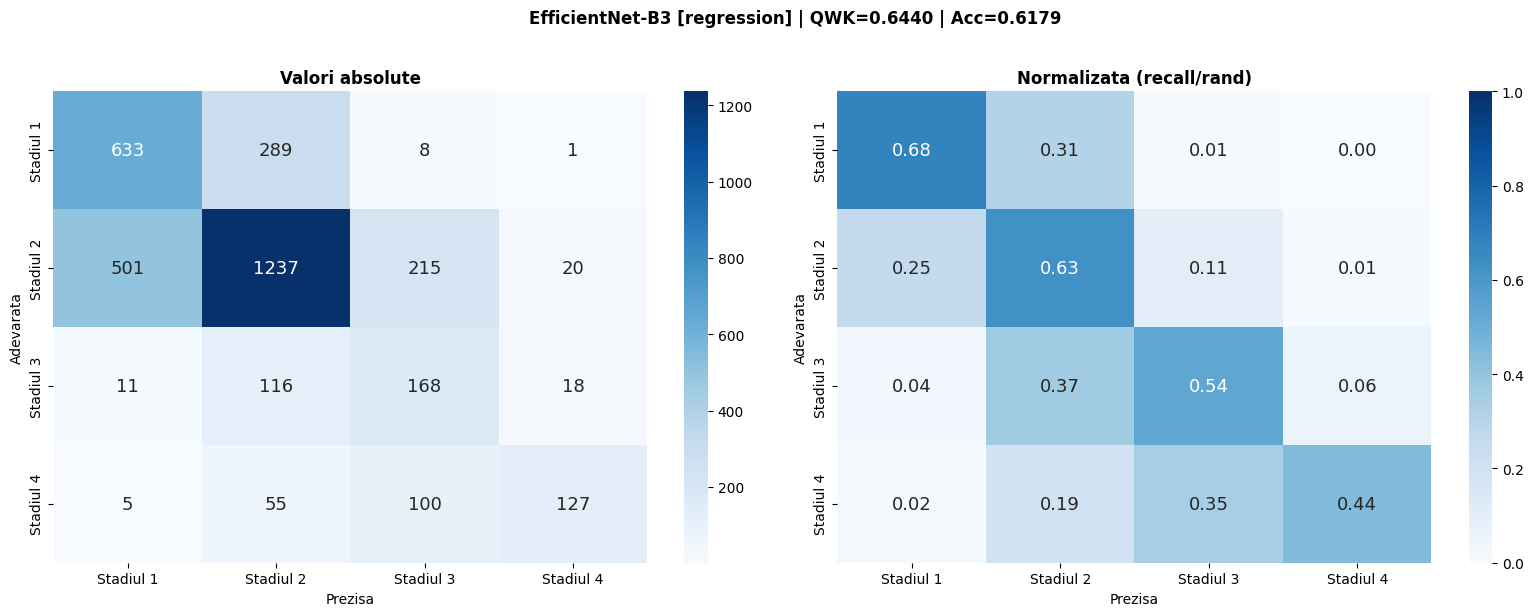


Distributia erorilor dupa distanta in grade:
  1 grad(e): 1239 (92.5% din erori)
  2 grad(e): 94 (7.0% din erori)
  3 grad(e): 6 (0.4% din erori)


In [11]:
model.load_state_dict(torch.load(CKPT)); model.eval()
print(f"=== EVALUARE PE TEST [{MODE}] ===")

# Pentru regresie: stringem scorurile continue ca sa fitam rounder-ul pe val
def collect(loader):
    preds, targets, scores = [], [], []
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="eval"):
            images = images.to(device)
            out = model(images)
            preds.extend(decode(out).cpu().tolist())
            targets.extend(labels.tolist())
            if MODE == "regression":
                scores.extend(raw_scores(out).cpu().numpy())
    return np.array(preds), np.array(targets), np.array(scores)

if MODE == "regression":
    _, val_t, val_s = collect(val_loader)
    rounder = OptimizedRounder(NUM_CLASSES); rounder.fit(val_s, val_t)
    print(f"Praguri optime (din val): {np.round(rounder.coef_, 3)}")
    _, test_t, test_s = collect(test_loader)
    test_p = rounder.predict(test_s)
else:
    test_p, test_t, _ = collect(test_loader)

test_acc = accuracy_score(test_t, test_p)
test_qwk = cohen_kappa_score(test_t, test_p, weights='quadratic')
print(f"\nTest Accuracy : {test_acc:.4f}")
print(f"Test QWK      : {test_qwk:.4f}\n")
print(classification_report(test_t, test_p, target_names=CLASS_NAMES, digits=3))

cm = confusion_matrix(test_t, test_p)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=axes[0], annot_kws={"size": 13})
axes[0].set_title('Valori absolute', fontweight='bold'); axes[0].set_ylabel('Adevarata'); axes[0].set_xlabel('Prezisa')
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=axes[1], annot_kws={"size": 13}, vmin=0, vmax=1)
axes[1].set_title('Normalizata (recall/rand)', fontweight='bold'); axes[1].set_ylabel('Adevarata'); axes[1].set_xlabel('Prezisa')
plt.suptitle(f'EfficientNet-B3 [{MODE}] | QWK={test_qwk:.4f} | Acc={test_acc:.4f}', fontweight='bold', y=1.02)
plt.tight_layout(); plt.savefig(f'matrice_confuzie_{MODE}.png', dpi=300, bbox_inches='tight'); plt.show()

# Erori adiacente vs. la distanta (relevant clinic + explica QWK)
err = test_p != test_t
if err.sum():
    d = np.abs(test_p[err] - test_t[err])
    print("\nDistributia erorilor dupa distanta in grade:")
    for k in sorted(np.unique(d)):
        c = (d == k).sum(); print(f"  {k} grad(e): {c} ({c/err.sum()*100:.1f}% din erori)")


# EfficientNet-B3 Multiclasă (grade 1-4) — 3 formulări comparabile

Acelaşi backbone, aceeaşi antrenare în două faze, aceleaşi date. Schimbi un singur comutator `MODE` şi obţii numere QWK comparabile între trei formulări ale problemei:

| `MODE` | Cap | Loss | De ce |
|---|---|---|---|
| `crossentropy` | 4 ieşiri (softmax) | CrossEntropy + **label smoothing 0.1** | baseline-ul tău actual, dar tratează clasele ca *nominale* (eroarea 1↔4 = eroarea 1↔2) |
| `regression` | 1 ieşire | SmoothL1 pe gradul continuu, apoi **rounder optimizat pe validare** | aliniat cu QWK; abordarea câştigătoare clasică pe EyePACS |
| `ordinal` | 3 ieşiri (CORAL) | CORAL loss (praguri cumulative monotone) | modelează explicit ordinea gradelor |

**Recomandare experimente pentru teză:** rulează toate trei cu acelaşi seed şi raportează QWK pe test într-un tabel. Povestea „am comparat formularea nominală vs. regresie vs. ordinală şi am ales-o pe cea cu QWK maxim" e exact tipul de contribuţie cerut.

> Etichetele interne sunt 0-3 (din `class_to_idx`: stadiul_1→0 … stadiul_4→3). QWK e identic indiferent de offset, deci nu trebuie să mapezi înapoi la 1-4 decât la afişare.

## Încărcare date și DataLoadere

In [12]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import models, transforms
from torch.utils.data import DataLoader, Subset
from tqdm import tqdm
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, cohen_kappa_score
import scipy.optimize as opt
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from pathlib import Path

# ================================================================
# CONFIGURARE
# ================================================================
DATA_DIR    = r'B:\Projects\Disertatie\Diabetic-Retinopathy-Classifier\datasets\processed_by_me\eyepacs\eyepacs_1_4'
IMG_SIZE    = 300
BATCH_SIZE  = 32
NUM_CLASSES = 4
CLASS_NAMES = ['Stadiul 1', 'Stadiul 2', 'Stadiul 3', 'Stadiul 4']
NUM_WORKERS = 8   # pe Windows: daca ingheata la granita dintre epoci, pune 0

_norm = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ToTensor(),
    _norm,
])
test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    _norm,
])

LOCAL_DIR = Path(r'B:\Projects\Disertatie\Diabetic-Retinopathy-Classifier\Notebooks\Main\Local')
if str(LOCAL_DIR) not in sys.path:
    sys.path.insert(0, str(LOCAL_DIR))
from dataset_1_4 import MultiClassRetinopathyDataset

train_ds = MultiClassRetinopathyDataset(os.path.join(DATA_DIR, 'train'), transform=train_transform)
val_ds   = MultiClassRetinopathyDataset(os.path.join(DATA_DIR, 'val'),   transform=test_transform)
test_ds  = MultiClassRetinopathyDataset(os.path.join(DATA_DIR, 'test'),  transform=test_transform)

loader_kwargs = {'num_workers': NUM_WORKERS, 'pin_memory': torch.cuda.is_available()}
if NUM_WORKERS > 0:
    loader_kwargs['prefetch_factor'] = 1

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  **loader_kwargs)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, **loader_kwargs)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, **loader_kwargs)

print("=== STATISTICI DATASET ===")
print(f"Mapare clase: {train_ds.class_to_idx}")
for split_name, ds in [("TRAIN", train_ds), ("VAL", val_ds), ("TEST", test_ds)]:
    targets = np.array(ds.targets)
    print(f"{split_name} ({len(ds)}): " + ", ".join(f"{c}={(targets==i).sum()}" for i,c in enumerate(CLASS_NAMES)))
print(f"Batch-uri train: {len(train_loader)}")


=== STATISTICI DATASET ===
Mapare clase: {'stadiul_1': 0, 'stadiul_2': 1, 'stadiul_3': 2, 'stadiul_4': 3}
TRAIN (40000): Stadiul 1=10000, Stadiul 2=10000, Stadiul 3=10000, Stadiul 4=10000
VAL (3503): Stadiul 1=930, Stadiul 2=1973, Stadiul 3=313, Stadiul 4=287
TEST (3504): Stadiul 1=931, Stadiul 2=1973, Stadiul 3=313, Stadiul 4=287
Batch-uri train: 1250


## Comutator MODE + capete, loss-uri și decodare

Aici se află toată logica specifică fiecărei formulări. Schimbă `MODE` și re-rulează de aici în jos.

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Antrenam pe: {device}")

# ================================================================
# >>> SCHIMBA DOAR ASTA <<<
MODE = "crossentropy"   # "crossentropy" | "regression" | "ordinal"
# ================================================================

HEAD_LR_PHASE1          = 1e-3
BACKBONE_LR_PHASE2      = 1e-4
HEAD_LR_PHASE2          = 3e-4
WEIGHT_DECAY            = 1e-4
DROPOUT                 = 0.40
FREEZE_BACKBONE_EPOCHS  = 3
TOTAL_EPOCHS            = 30
EARLY_STOPPING_PATIENCE = 6
LABEL_SMOOTHING         = 0.10   # folosit doar la crossentropy
SEED                    = 42

torch.manual_seed(SEED); np.random.seed(SEED)

# ---------------- CORAL (mod ordinal) ----------------
class CoralLayer(nn.Module):
    """Un singur set de ponderi + K-1 bias-uri independente => praguri monotone."""
    def __init__(self, in_features, num_classes):
        super().__init__()
        self.fc = nn.Linear(in_features, 1, bias=False)
        self.bias = nn.Parameter(torch.zeros(num_classes - 1).float())
    def forward(self, x):
        return self.fc(x) + self.bias            # [B, K-1]

def labels_to_levels(labels, num_classes):
    rng = torch.arange(num_classes - 1, device=labels.device).unsqueeze(0)
    return (labels.unsqueeze(1) > rng).float()    # ex: label 2 -> [1,1,0]

def coral_loss(logits, levels):
    return (-torch.sum(F.logsigmoid(logits) * levels
            + (F.logsigmoid(logits) - logits) * (1 - levels), dim=1)).mean()

def coral_decode(logits):
    return (torch.sigmoid(logits) > 0.5).sum(dim=1)   # numara cate praguri sunt depasite

# ---------------- Construire model in functie de MODE ----------------
def build_model(mode):
    m = models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.IMAGENET1K_V1)
    nf = m.classifier[1].in_features
    if mode == "crossentropy":
        m.classifier[1] = nn.Sequential(nn.Dropout(DROPOUT), nn.Linear(nf, NUM_CLASSES))
    elif mode == "regression":
        m.classifier[1] = nn.Sequential(nn.Dropout(DROPOUT), nn.Linear(nf, 1))
    elif mode == "ordinal":
        m.classifier = nn.Sequential(nn.Dropout(DROPOUT), CoralLayer(nf, NUM_CLASSES))
    else:
        raise ValueError(f"MODE necunoscut: {mode}")
    return m.to(device)

model = build_model(MODE)
ce_criterion  = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
reg_criterion = nn.SmoothL1Loss()

def compute_loss(out, labels):
    if MODE == "crossentropy":
        return ce_criterion(out, labels)
    if MODE == "regression":
        return reg_criterion(out.squeeze(1), labels.float())
    if MODE == "ordinal":
        return coral_loss(out, labels_to_levels(labels, NUM_CLASSES))

def decode(out):
    """Predictii intregi 0..K-1 pentru monitorizare (regresie: rotunjire naiva)."""
    if MODE == "crossentropy":
        return out.argmax(1)
    if MODE == "regression":
        return out.squeeze(1).round().clamp(0, NUM_CLASSES - 1).long()
    if MODE == "ordinal":
        return coral_decode(out)

def raw_scores(out):
    """Iesirea continua pentru regresie (necesara la rounder-ul optimizat)."""
    return out.squeeze(1) if MODE == "regression" else None

# ---------------- Rounder optimizat pe validare (doar regresie) ----------------
class OptimizedRounder:
    """Alege K-1 praguri care maximizeaza QWK pe validare (Nelder-Mead)."""
    def __init__(self, n_classes): self.n_classes = n_classes; self.coef_ = None
    def _classify(self, X, coef):
        return np.clip(np.digitize(X, np.sort(coef)), 0, self.n_classes - 1)
    def _neg_qwk(self, coef, X, y):
        return -cohen_kappa_score(y, self._classify(X, coef), weights='quadratic')
    def fit(self, X, y):
        init = np.arange(self.n_classes - 1) + 0.5
        r = opt.minimize(self._neg_qwk, init, args=(X, y), method='Nelder-Mead')
        self.coef_ = np.sort(r.x)
    def predict(self, X):
        return self._classify(X, self.coef_)

# ---------------- Freeze/unfreeze + optimizatoare pe faze ----------------
def set_backbone_trainable(m, trainable):
    for name, p in m.named_parameters():
        if not name.startswith("classifier"):
            p.requires_grad = trainable

def split_params(m):
    head     = [p for n, p in m.named_parameters() if n.startswith("classifier")]
    backbone = [p for n, p in m.named_parameters() if not n.startswith("classifier")]
    return head, backbone

def build_optimizer_phase1(m):
    set_backbone_trainable(m, False)
    head, _ = split_params(m)
    o = optim.AdamW(head, lr=HEAD_LR_PHASE1, weight_decay=WEIGHT_DECAY)
    s = optim.lr_scheduler.ReduceLROnPlateau(o, mode='max', factor=0.5, patience=2)
    return o, s

def build_optimizer_phase2(m):
    set_backbone_trainable(m, True)
    head, backbone = split_params(m)
    o = optim.AdamW([{"params": backbone, "lr": BACKBONE_LR_PHASE2},
                     {"params": head,     "lr": HEAD_LR_PHASE2}], weight_decay=WEIGHT_DECAY)
    s = optim.lr_scheduler.ReduceLROnPlateau(o, mode='max', factor=0.5, patience=2)
    return o, s

scaler = torch.amp.GradScaler('cuda')
CKPT = f'efficientnet_b3_multiclass_{MODE}.pth'
print(f"MODE = {MODE} | checkpoint -> {CKPT}")


Antrenam pe: cuda
MODE = crossentropy | checkpoint -> efficientnet_b3_multiclass_crossentropy.pth


## (Opțional) Sanity-check: poate modelul memora 100 imagini?

In [14]:
RUN_SANITY = True

if RUN_SANITY:
    import copy
    small = Subset(train_ds, list(range(100)))
    small_loader = DataLoader(small, batch_size=16, shuffle=True, num_workers=0)
    m = copy.deepcopy(model); set_backbone_trainable(m, True)
    o = optim.AdamW(m.parameters(), lr=1e-4, weight_decay=0)
    for ep in range(20):
        m.train(); preds, tgts = [], []
        for images, labels in small_loader:
            images, labels = images.to(device), labels.to(device)
            o.zero_grad()
            with torch.amp.autocast('cuda', enabled=(device.type=='cuda')):
                out = m(images); loss = compute_loss(out, labels)
            scaler.scale(loss).backward(); scaler.step(o); scaler.update()
            preds += decode(out).detach().cpu().tolist(); tgts += labels.cpu().tolist()
        print(f"sanity epoca {ep+1}: train_acc={accuracy_score(tgts, preds):.3f}")
    print("~1.0 -> pipeline OK | ~0.25 -> problema in date/etichete")
else:
    print("Sanity-check dezactivat.")


sanity epoca 1: train_acc=0.670
sanity epoca 2: train_acc=0.980
sanity epoca 3: train_acc=1.000
sanity epoca 4: train_acc=1.000
sanity epoca 5: train_acc=1.000
sanity epoca 6: train_acc=1.000
sanity epoca 7: train_acc=1.000
sanity epoca 8: train_acc=1.000
sanity epoca 9: train_acc=1.000
sanity epoca 10: train_acc=1.000
sanity epoca 11: train_acc=1.000
sanity epoca 12: train_acc=1.000
sanity epoca 13: train_acc=1.000
sanity epoca 14: train_acc=1.000
sanity epoca 15: train_acc=1.000
sanity epoca 16: train_acc=1.000
sanity epoca 17: train_acc=1.000
sanity epoca 18: train_acc=1.000
sanity epoca 19: train_acc=1.000
sanity epoca 20: train_acc=1.000
~1.0 -> pipeline OK | ~0.25 -> problema in date/etichete


## Antrenare (două faze + early stopping pe QWK)

In [15]:
optimizer, scheduler = build_optimizer_phase1(model)
best_val_qwk = -1.0
epochs_no_improve = 0
history = {'t_loss': [], 'v_loss': [], 'v_acc': [], 'v_qwk': []}

print(f"=== ANTRENARE [{MODE}] - FAZA 1 (backbone inghetat) ===")

for epoch in range(TOTAL_EPOCHS):
    if epoch == FREEZE_BACKBONE_EPOCHS:
        optimizer, scheduler = build_optimizer_phase2(model)
        print("=== FAZA 2: backbone dezghetat, fine-tuning complet ===")

    # ---- TRAIN ----
    model.train(); train_loss = 0.0
    for images, labels in tqdm(train_loader, desc=f"Epoca {epoch+1}/{TOTAL_EPOCHS} [TRAIN]"):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast('cuda', enabled=(device.type=='cuda')):
            out = model(images); loss = compute_loss(out, labels)
        scaler.scale(loss).backward(); scaler.step(optimizer); scaler.update()
        train_loss += loss.item() * images.size(0)

    # ---- VAL ----
    model.eval(); val_loss = 0.0; val_preds, val_targets = [], []
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc=f"Epoca {epoch+1}/{TOTAL_EPOCHS} [VAL]"):
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            with torch.amp.autocast('cuda', enabled=(device.type=='cuda')):
                out = model(images); loss = compute_loss(out, labels)
            val_loss += loss.item() * images.size(0)
            val_preds.extend(decode(out).detach().cpu().tolist())
            val_targets.extend(labels.detach().cpu().tolist())

    avg_train_loss = train_loss / len(train_ds)
    avg_val_loss   = val_loss / len(val_ds)
    val_acc = accuracy_score(val_targets, val_preds)
    val_qwk = cohen_kappa_score(val_targets, val_preds, weights='quadratic')
    for k, v in zip(history, [avg_train_loss, avg_val_loss, val_acc, val_qwk]):
        history[k].append(v)
    scheduler.step(val_qwk)

    print(f"Epoca {epoch+1}: T_Loss={avg_train_loss:.4f} | V_Loss={avg_val_loss:.4f} "
          f"| V_Acc={val_acc:.4f} | V_QWK={val_qwk:.4f}")

    if val_qwk > best_val_qwk + 1e-4:
        best_val_qwk = val_qwk; epochs_no_improve = 0
        torch.save(model.state_dict(), CKPT)
        print(f"Model nou salvat! (Val QWK: {best_val_qwk:.4f})")
    else:
        epochs_no_improve += 1
        print(f"Fara imbunatatire pe QWK: {epochs_no_improve}/{EARLY_STOPPING_PATIENCE}")
        if epochs_no_improve >= EARLY_STOPPING_PATIENCE:
            print("Early stopping."); break

print(f"Cel mai bun Val QWK [{MODE}]: {best_val_qwk:.4f}")


=== ANTRENARE [crossentropy] - FAZA 1 (backbone inghetat) ===


Epoca 1/30 [VAL]: 100%|██████████| 110/110 [00:38<00:00,  2.82it/s]


Epoca 1: T_Loss=1.1951 | V_Loss=1.0535 | V_Acc=0.5775 | V_QWK=0.3823
Model nou salvat! (Val QWK: 0.3823)


Epoca 2/30 [VAL]: 100%|██████████| 110/110 [00:36<00:00,  3.01it/s]


Epoca 2: T_Loss=1.1762 | V_Loss=1.0444 | V_Acc=0.5792 | V_QWK=0.3546
Fara imbunatatire pe QWK: 1/6


...

Epoca 12: T_Loss=0.5257 | V_Loss=0.9606 | V_Acc=0.6788 | V_QWK=0.6244
Fara imbunatatire pe QWK: 4/6


Epoca 13/30 [VAL]: 100%|██████████| 110/110 [00:39<00:00,  2.81it/s]


Epoca 13: T_Loss=0.5104 | V_Loss=0.9603 | V_Acc=0.6800 | V_QWK=0.6189
Fara imbunatatire pe QWK: 5/6


Epoca 14/30 [VAL]: 100%|██████████| 110/110 [00:36<00:00,  3.01it/s]

Epoca 14: T_Loss=0.4982 | V_Loss=0.9900 | V_Acc=0.6754 | V_QWK=0.6154
Fara imbunatatire pe QWK: 6/6
Early stopping.
Cel mai bun Val QWK [crossentropy]: 0.6429


## Curbe de antrenare

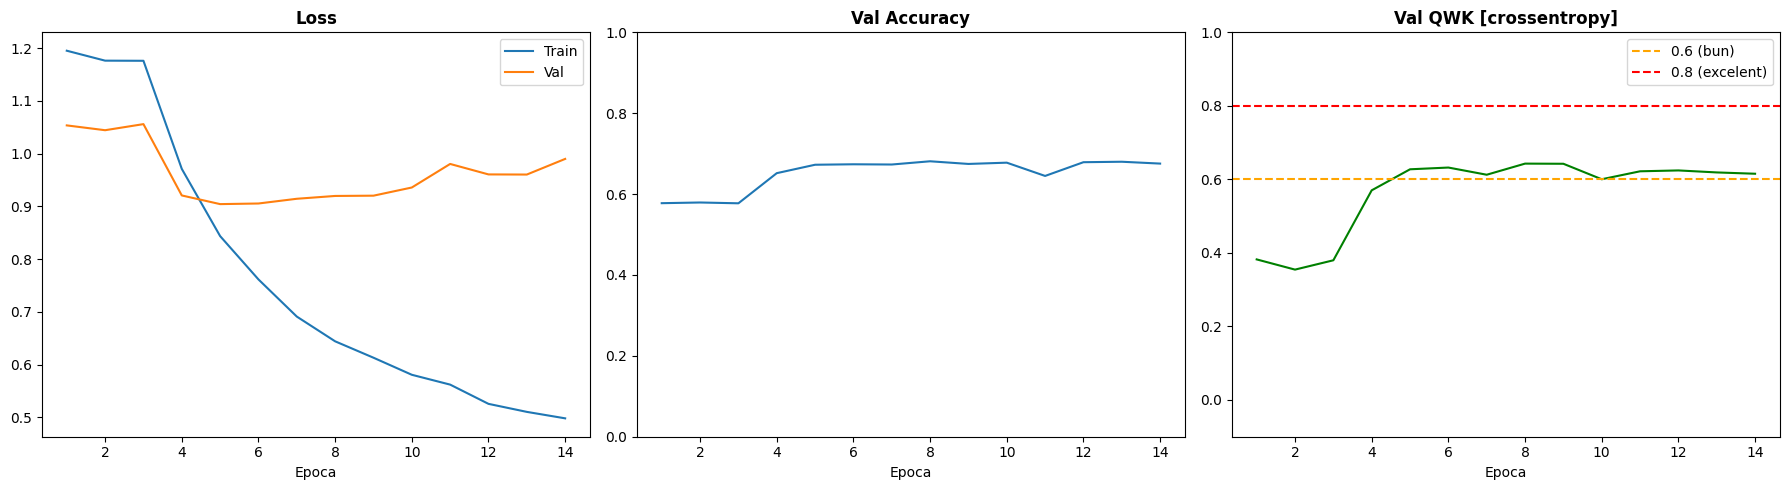

In [16]:
xs = range(1, len(history['t_loss']) + 1)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(xs, history['t_loss'], label='Train'); axes[0].plot(xs, history['v_loss'], label='Val')
axes[0].set_title('Loss', fontweight='bold'); axes[0].legend(); axes[0].set_xlabel('Epoca')
axes[1].plot(xs, history['v_acc']); axes[1].set_title('Val Accuracy', fontweight='bold')
axes[1].set_xlabel('Epoca'); axes[1].set_ylim(0, 1)
axes[2].plot(xs, history['v_qwk'], color='green'); axes[2].set_title(f'Val QWK [{MODE}]', fontweight='bold')
axes[2].set_xlabel('Epoca'); axes[2].set_ylim(-0.1, 1)
axes[2].axhline(0.6, color='orange', ls='--', label='0.6 (bun)')
axes[2].axhline(0.8, color='red', ls='--', label='0.8 (excelent)'); axes[2].legend()
plt.tight_layout(); plt.savefig(f'curbe_{MODE}.png', dpi=150, bbox_inches='tight'); plt.show()


## Evaluare pe test

Pentru `regression`, pragurile de rotunjire sunt **optimizate pe validare** (QWK maxim) și apoi aplicate pe test — niciodată ajustate pe test. Pentru celelalte moduri, decodarea e directă.

=== EVALUARE PE TEST [crossentropy] ===


eval: 100%|██████████| 110/110 [00:41<00:00,  2.62it/s]



Test Accuracy : 0.6618
Test QWK      : 0.6247

              precision    recall  f1-score   support

   Stadiul 1      0.610     0.636     0.623       931
   Stadiul 2      0.710     0.737     0.723      1973
   Stadiul 3      0.460     0.390     0.422       313
   Stadiul 4      0.686     0.526     0.596       287

    accuracy                          0.662      3504
   macro avg      0.617     0.572     0.591      3504
weighted avg      0.659     0.662     0.659      3504



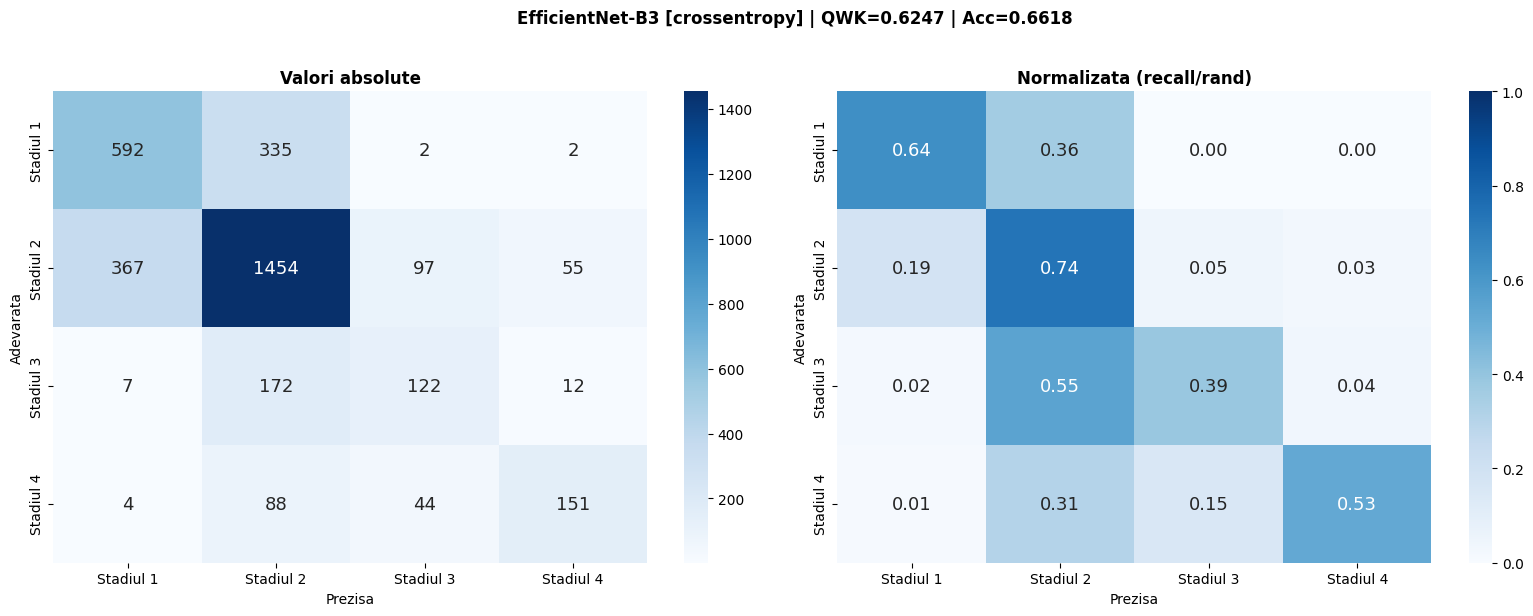


Distributia erorilor dupa distanta in grade:
  1 grad(e): 1027 (86.7% din erori)
  2 grad(e): 152 (12.8% din erori)
  3 grad(e): 6 (0.5% din erori)


In [17]:
model.load_state_dict(torch.load(CKPT)); model.eval()
print(f"=== EVALUARE PE TEST [{MODE}] ===")

# Pentru regresie: stringem scorurile continue ca sa fitam rounder-ul pe val
def collect(loader):
    preds, targets, scores = [], [], []
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="eval"):
            images = images.to(device)
            out = model(images)
            preds.extend(decode(out).cpu().tolist())
            targets.extend(labels.tolist())
            if MODE == "regression":
                scores.extend(raw_scores(out).cpu().numpy())
    return np.array(preds), np.array(targets), np.array(scores)

if MODE == "regression":
    _, val_t, val_s = collect(val_loader)
    rounder = OptimizedRounder(NUM_CLASSES); rounder.fit(val_s, val_t)
    print(f"Praguri optime (din val): {np.round(rounder.coef_, 3)}")
    _, test_t, test_s = collect(test_loader)
    test_p = rounder.predict(test_s)
else:
    test_p, test_t, _ = collect(test_loader)

test_acc = accuracy_score(test_t, test_p)
test_qwk = cohen_kappa_score(test_t, test_p, weights='quadratic')
print(f"\nTest Accuracy : {test_acc:.4f}")
print(f"Test QWK      : {test_qwk:.4f}\n")
print(classification_report(test_t, test_p, target_names=CLASS_NAMES, digits=3))

cm = confusion_matrix(test_t, test_p)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=axes[0], annot_kws={"size": 13})
axes[0].set_title('Valori absolute', fontweight='bold'); axes[0].set_ylabel('Adevarata'); axes[0].set_xlabel('Prezisa')
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=axes[1], annot_kws={"size": 13}, vmin=0, vmax=1)
axes[1].set_title('Normalizata (recall/rand)', fontweight='bold'); axes[1].set_ylabel('Adevarata'); axes[1].set_xlabel('Prezisa')
plt.suptitle(f'EfficientNet-B3 [{MODE}] | QWK={test_qwk:.4f} | Acc={test_acc:.4f}', fontweight='bold', y=1.02)
plt.tight_layout(); plt.savefig(f'matrice_confuzie_{MODE}.png', dpi=300, bbox_inches='tight'); plt.show()

# Erori adiacente vs. la distanta (relevant clinic + explica QWK)
err = test_p != test_t
if err.sum():
    d = np.abs(test_p[err] - test_t[err])
    print("\nDistributia erorilor dupa distanta in grade:")
    for k in sorted(np.unique(d)):
        c = (d == k).sum(); print(f"  {k} grad(e): {c} ({c/err.sum()*100:.1f}% din erori)")


# EfficientNet-B3 Multiclasă (grade 1-4) — 3 formulări comparabile

Acelaşi backbone, aceeaşi antrenare în două faze, aceleaşi date. Schimbi un singur comutator `MODE` şi obţii numere QWK comparabile între trei formulări ale problemei:

| `MODE` | Cap | Loss | De ce |
|---|---|---|---|
| `crossentropy` | 4 ieşiri (softmax) | CrossEntropy + **label smoothing 0.1** | baseline-ul tău actual, dar tratează clasele ca *nominale* (eroarea 1↔4 = eroarea 1↔2) |
| `regression` | 1 ieşire | SmoothL1 pe gradul continuu, apoi **rounder optimizat pe validare** | aliniat cu QWK; abordarea câştigătoare clasică pe EyePACS |
| `ordinal` | 3 ieşiri (CORAL) | CORAL loss (praguri cumulative monotone) | modelează explicit ordinea gradelor |

**Recomandare experimente pentru teză:** rulează toate trei cu acelaşi seed şi raportează QWK pe test într-un tabel. Povestea „am comparat formularea nominală vs. regresie vs. ordinală şi am ales-o pe cea cu QWK maxim" e exact tipul de contribuţie cerut.

> Etichetele interne sunt 0-3 (din `class_to_idx`: stadiul_1→0 … stadiul_4→3). QWK e identic indiferent de offset, deci nu trebuie să mapezi înapoi la 1-4 decât la afişare.

## Încărcare date și DataLoadere

In [18]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import models, transforms
from torch.utils.data import DataLoader, Subset
from tqdm import tqdm
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, cohen_kappa_score
import scipy.optimize as opt
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from pathlib import Path

# ================================================================
# CONFIGURARE
# ================================================================
DATA_DIR    = r'B:\Projects\Disertatie\Diabetic-Retinopathy-Classifier\datasets\processed_by_me\eyepacs\eyepacs_1_4'
IMG_SIZE    = 300
BATCH_SIZE  = 32
NUM_CLASSES = 4
CLASS_NAMES = ['Stadiul 1', 'Stadiul 2', 'Stadiul 3', 'Stadiul 4']
NUM_WORKERS = 8   # pe Windows: daca ingheata la granita dintre epoci, pune 0

_norm = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ToTensor(),
    _norm,
])
test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    _norm,
])

LOCAL_DIR = Path(r'B:\Projects\Disertatie\Diabetic-Retinopathy-Classifier\Notebooks\Main\Local')
if str(LOCAL_DIR) not in sys.path:
    sys.path.insert(0, str(LOCAL_DIR))
from dataset_1_4 import MultiClassRetinopathyDataset

train_ds = MultiClassRetinopathyDataset(os.path.join(DATA_DIR, 'train'), transform=train_transform)
val_ds   = MultiClassRetinopathyDataset(os.path.join(DATA_DIR, 'val'),   transform=test_transform)
test_ds  = MultiClassRetinopathyDataset(os.path.join(DATA_DIR, 'test'),  transform=test_transform)

loader_kwargs = {'num_workers': NUM_WORKERS, 'pin_memory': torch.cuda.is_available()}
if NUM_WORKERS > 0:
    loader_kwargs['prefetch_factor'] = 1

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  **loader_kwargs)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, **loader_kwargs)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, **loader_kwargs)

print("=== STATISTICI DATASET ===")
print(f"Mapare clase: {train_ds.class_to_idx}")
for split_name, ds in [("TRAIN", train_ds), ("VAL", val_ds), ("TEST", test_ds)]:
    targets = np.array(ds.targets)
    print(f"{split_name} ({len(ds)}): " + ", ".join(f"{c}={(targets==i).sum()}" for i,c in enumerate(CLASS_NAMES)))
print(f"Batch-uri train: {len(train_loader)}")


=== STATISTICI DATASET ===
Mapare clase: {'stadiul_1': 0, 'stadiul_2': 1, 'stadiul_3': 2, 'stadiul_4': 3}
TRAIN (40000): Stadiul 1=10000, Stadiul 2=10000, Stadiul 3=10000, Stadiul 4=10000
VAL (3503): Stadiul 1=930, Stadiul 2=1973, Stadiul 3=313, Stadiul 4=287
TEST (3504): Stadiul 1=931, Stadiul 2=1973, Stadiul 3=313, Stadiul 4=287
Batch-uri train: 1250


## Comutator MODE + capete, loss-uri și decodare

Aici se află toată logica specifică fiecărei formulări. Schimbă `MODE` și re-rulează de aici în jos.

In [19]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Antrenam pe: {device}")

# ================================================================
# >>> SCHIMBA DOAR ASTA <<<
MODE = "ordinal"   # "crossentropy" | "regression" | "ordinal"
# ================================================================

HEAD_LR_PHASE1          = 1e-3
BACKBONE_LR_PHASE2      = 1e-4
HEAD_LR_PHASE2          = 3e-4
WEIGHT_DECAY            = 1e-4
DROPOUT                 = 0.40
FREEZE_BACKBONE_EPOCHS  = 3
TOTAL_EPOCHS            = 30
EARLY_STOPPING_PATIENCE = 6
LABEL_SMOOTHING         = 0.10   # folosit doar la crossentropy
SEED                    = 42

torch.manual_seed(SEED); np.random.seed(SEED)

# ---------------- CORAL (mod ordinal) ----------------
class CoralLayer(nn.Module):
    """Un singur set de ponderi + K-1 bias-uri independente => praguri monotone."""
    def __init__(self, in_features, num_classes):
        super().__init__()
        self.fc = nn.Linear(in_features, 1, bias=False)
        self.bias = nn.Parameter(torch.zeros(num_classes - 1).float())
    def forward(self, x):
        return self.fc(x) + self.bias            # [B, K-1]

def labels_to_levels(labels, num_classes):
    rng = torch.arange(num_classes - 1, device=labels.device).unsqueeze(0)
    return (labels.unsqueeze(1) > rng).float()    # ex: label 2 -> [1,1,0]

def coral_loss(logits, levels):
    return (-torch.sum(F.logsigmoid(logits) * levels
            + (F.logsigmoid(logits) - logits) * (1 - levels), dim=1)).mean()

def coral_decode(logits):
    return (torch.sigmoid(logits) > 0.5).sum(dim=1)   # numara cate praguri sunt depasite

# ---------------- Construire model in functie de MODE ----------------
def build_model(mode):
    m = models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.IMAGENET1K_V1)
    nf = m.classifier[1].in_features
    if mode == "crossentropy":
        m.classifier[1] = nn.Sequential(nn.Dropout(DROPOUT), nn.Linear(nf, NUM_CLASSES))
    elif mode == "regression":
        m.classifier[1] = nn.Sequential(nn.Dropout(DROPOUT), nn.Linear(nf, 1))
    elif mode == "ordinal":
        m.classifier = nn.Sequential(nn.Dropout(DROPOUT), CoralLayer(nf, NUM_CLASSES))
    else:
        raise ValueError(f"MODE necunoscut: {mode}")
    return m.to(device)

model = build_model(MODE)
ce_criterion  = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
reg_criterion = nn.SmoothL1Loss()

def compute_loss(out, labels):
    if MODE == "crossentropy":
        return ce_criterion(out, labels)
    if MODE == "regression":
        return reg_criterion(out.squeeze(1), labels.float())
    if MODE == "ordinal":
        return coral_loss(out, labels_to_levels(labels, NUM_CLASSES))

def decode(out):
    """Predictii intregi 0..K-1 pentru monitorizare (regresie: rotunjire naiva)."""
    if MODE == "crossentropy":
        return out.argmax(1)
    if MODE == "regression":
        return out.squeeze(1).round().clamp(0, NUM_CLASSES - 1).long()
    if MODE == "ordinal":
        return coral_decode(out)

def raw_scores(out):
    """Iesirea continua pentru regresie (necesara la rounder-ul optimizat)."""
    return out.squeeze(1) if MODE == "regression" else None

# ---------------- Rounder optimizat pe validare (doar regresie) ----------------
class OptimizedRounder:
    """Alege K-1 praguri care maximizeaza QWK pe validare (Nelder-Mead)."""
    def __init__(self, n_classes): self.n_classes = n_classes; self.coef_ = None
    def _classify(self, X, coef):
        return np.clip(np.digitize(X, np.sort(coef)), 0, self.n_classes - 1)
    def _neg_qwk(self, coef, X, y):
        return -cohen_kappa_score(y, self._classify(X, coef), weights='quadratic')
    def fit(self, X, y):
        init = np.arange(self.n_classes - 1) + 0.5
        r = opt.minimize(self._neg_qwk, init, args=(X, y), method='Nelder-Mead')
        self.coef_ = np.sort(r.x)
    def predict(self, X):
        return self._classify(X, self.coef_)

# ---------------- Freeze/unfreeze + optimizatoare pe faze ----------------
def set_backbone_trainable(m, trainable):
    for name, p in m.named_parameters():
        if not name.startswith("classifier"):
            p.requires_grad = trainable

def split_params(m):
    head     = [p for n, p in m.named_parameters() if n.startswith("classifier")]
    backbone = [p for n, p in m.named_parameters() if not n.startswith("classifier")]
    return head, backbone

def build_optimizer_phase1(m):
    set_backbone_trainable(m, False)
    head, _ = split_params(m)
    o = optim.AdamW(head, lr=HEAD_LR_PHASE1, weight_decay=WEIGHT_DECAY)
    s = optim.lr_scheduler.ReduceLROnPlateau(o, mode='max', factor=0.5, patience=2)
    return o, s

def build_optimizer_phase2(m):
    set_backbone_trainable(m, True)
    head, backbone = split_params(m)
    o = optim.AdamW([{"params": backbone, "lr": BACKBONE_LR_PHASE2},
                     {"params": head,     "lr": HEAD_LR_PHASE2}], weight_decay=WEIGHT_DECAY)
    s = optim.lr_scheduler.ReduceLROnPlateau(o, mode='max', factor=0.5, patience=2)
    return o, s

scaler = torch.amp.GradScaler('cuda')
CKPT = f'efficientnet_b3_multiclass_{MODE}.pth'
print(f"MODE = {MODE} | checkpoint -> {CKPT}")


Antrenam pe: cuda
MODE = ordinal | checkpoint -> efficientnet_b3_multiclass_ordinal.pth


## (Opțional) Sanity-check: poate modelul memora 100 imagini?

In [20]:
RUN_SANITY = True

if RUN_SANITY:
    import copy
    small = Subset(train_ds, list(range(100)))
    small_loader = DataLoader(small, batch_size=16, shuffle=True, num_workers=0)
    m = copy.deepcopy(model); set_backbone_trainable(m, True)
    o = optim.AdamW(m.parameters(), lr=1e-4, weight_decay=0)
    for ep in range(20):
        m.train(); preds, tgts = [], []
        for images, labels in small_loader:
            images, labels = images.to(device), labels.to(device)
            o.zero_grad()
            with torch.amp.autocast('cuda', enabled=(device.type=='cuda')):
                out = m(images); loss = compute_loss(out, labels)
            scaler.scale(loss).backward(); scaler.step(o); scaler.update()
            preds += decode(out).detach().cpu().tolist(); tgts += labels.cpu().tolist()
        print(f"sanity epoca {ep+1}: train_acc={accuracy_score(tgts, preds):.3f}")
    print("~1.0 -> pipeline OK | ~0.25 -> problema in date/etichete")
else:
    print("Sanity-check dezactivat.")


sanity epoca 1: train_acc=0.540
sanity epoca 2: train_acc=0.990
sanity epoca 3: train_acc=1.000
sanity epoca 4: train_acc=1.000
sanity epoca 5: train_acc=1.000
sanity epoca 6: train_acc=1.000
sanity epoca 7: train_acc=1.000
sanity epoca 8: train_acc=1.000
sanity epoca 9: train_acc=1.000
sanity epoca 10: train_acc=1.000
sanity epoca 11: train_acc=1.000
sanity epoca 12: train_acc=1.000
sanity epoca 13: train_acc=1.000
sanity epoca 14: train_acc=1.000
sanity epoca 15: train_acc=1.000
sanity epoca 16: train_acc=1.000
sanity epoca 17: train_acc=1.000
sanity epoca 18: train_acc=1.000
sanity epoca 19: train_acc=1.000
sanity epoca 20: train_acc=1.000
~1.0 -> pipeline OK | ~0.25 -> problema in date/etichete


## Antrenare (două faze + early stopping pe QWK)

In [21]:
optimizer, scheduler = build_optimizer_phase1(model)
best_val_qwk = -1.0
epochs_no_improve = 0
history = {'t_loss': [], 'v_loss': [], 'v_acc': [], 'v_qwk': []}

print(f"=== ANTRENARE [{MODE}] - FAZA 1 (backbone inghetat) ===")

for epoch in range(TOTAL_EPOCHS):
    if epoch == FREEZE_BACKBONE_EPOCHS:
        optimizer, scheduler = build_optimizer_phase2(model)
        print("=== FAZA 2: backbone dezghetat, fine-tuning complet ===")

    # ---- TRAIN ----
    model.train(); train_loss = 0.0
    for images, labels in tqdm(train_loader, desc=f"Epoca {epoch+1}/{TOTAL_EPOCHS} [TRAIN]"):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast('cuda', enabled=(device.type=='cuda')):
            out = model(images); loss = compute_loss(out, labels)
        scaler.scale(loss).backward(); scaler.step(optimizer); scaler.update()
        train_loss += loss.item() * images.size(0)

    # ---- VAL ----
    model.eval(); val_loss = 0.0; val_preds, val_targets = [], []
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc=f"Epoca {epoch+1}/{TOTAL_EPOCHS} [VAL]"):
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            with torch.amp.autocast('cuda', enabled=(device.type=='cuda')):
                out = model(images); loss = compute_loss(out, labels)
            val_loss += loss.item() * images.size(0)
            val_preds.extend(decode(out).detach().cpu().tolist())
            val_targets.extend(labels.detach().cpu().tolist())

    avg_train_loss = train_loss / len(train_ds)
    avg_val_loss   = val_loss / len(val_ds)
    val_acc = accuracy_score(val_targets, val_preds)
    val_qwk = cohen_kappa_score(val_targets, val_preds, weights='quadratic')
    for k, v in zip(history, [avg_train_loss, avg_val_loss, val_acc, val_qwk]):
        history[k].append(v)
    scheduler.step(val_qwk)

    print(f"Epoca {epoch+1}: T_Loss={avg_train_loss:.4f} | V_Loss={avg_val_loss:.4f} "
          f"| V_Acc={val_acc:.4f} | V_QWK={val_qwk:.4f}")

    if val_qwk > best_val_qwk + 1e-4:
        best_val_qwk = val_qwk; epochs_no_improve = 0
        torch.save(model.state_dict(), CKPT)
        print(f"Model nou salvat! (Val QWK: {best_val_qwk:.4f})")
    else:
        epochs_no_improve += 1
        print(f"Fara imbunatatire pe QWK: {epochs_no_improve}/{EARLY_STOPPING_PATIENCE}")
        if epochs_no_improve >= EARLY_STOPPING_PATIENCE:
            print("Early stopping."); break

print(f"Cel mai bun Val QWK [{MODE}]: {best_val_qwk:.4f}")


=== ANTRENARE [ordinal] - FAZA 1 (backbone inghetat) ===


Epoca 1/30 [VAL]: 100%|██████████| 110/110 [00:38<00:00,  2.83it/s]


Epoca 1: T_Loss=1.5780 | V_Loss=1.3452 | V_Acc=0.4385 | V_QWK=0.4768
Model nou salvat! (Val QWK: 0.4768)


Epoca 2/30 [VAL]: 100%|██████████| 110/110 [00:36<00:00,  3.00it/s]


Epoca 2: T_Loss=1.4113 | V_Loss=1.2379 | V_Acc=0.4779 | V_QWK=0.4914
Model nou salvat! (Val QWK: 0.4914)


...

Epoca 10: T_Loss=0.5159 | V_Loss=0.9511 | V_Acc=0.6417 | V_QWK=0.6451
Fara imbunatatire pe QWK: 4/6


Epoca 11/30 [VAL]: 100%|██████████| 110/110 [00:40<00:00,  2.74it/s]


Epoca 11: T_Loss=0.4766 | V_Loss=0.9475 | V_Acc=0.6346 | V_QWK=0.6568
Fara imbunatatire pe QWK: 5/6


Epoca 12/30 [VAL]: 100%|██████████| 110/110 [00:39<00:00,  2.81it/s]

Epoca 12: T_Loss=0.4478 | V_Loss=1.0021 | V_Acc=0.6209 | V_QWK=0.6492
Fara imbunatatire pe QWK: 6/6
Early stopping.
Cel mai bun Val QWK [ordinal]: 0.6567


## Curbe de antrenare

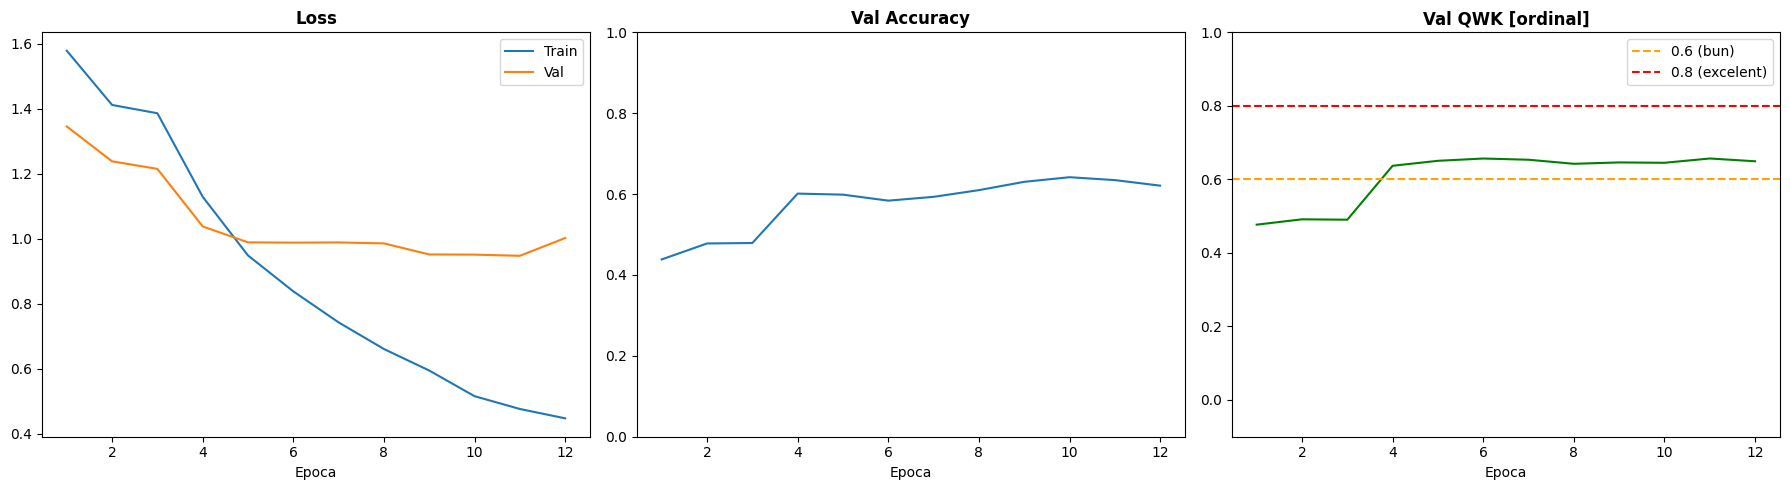

In [22]:
xs = range(1, len(history['t_loss']) + 1)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(xs, history['t_loss'], label='Train'); axes[0].plot(xs, history['v_loss'], label='Val')
axes[0].set_title('Loss', fontweight='bold'); axes[0].legend(); axes[0].set_xlabel('Epoca')
axes[1].plot(xs, history['v_acc']); axes[1].set_title('Val Accuracy', fontweight='bold')
axes[1].set_xlabel('Epoca'); axes[1].set_ylim(0, 1)
axes[2].plot(xs, history['v_qwk'], color='green'); axes[2].set_title(f'Val QWK [{MODE}]', fontweight='bold')
axes[2].set_xlabel('Epoca'); axes[2].set_ylim(-0.1, 1)
axes[2].axhline(0.6, color='orange', ls='--', label='0.6 (bun)')
axes[2].axhline(0.8, color='red', ls='--', label='0.8 (excelent)'); axes[2].legend()
plt.tight_layout(); plt.savefig(f'curbe_{MODE}.png', dpi=150, bbox_inches='tight'); plt.show()


## Evaluare pe test

Pentru `regression`, pragurile de rotunjire sunt **optimizate pe validare** (QWK maxim) și apoi aplicate pe test — niciodată ajustate pe test. Pentru celelalte moduri, decodarea e directă.

=== EVALUARE PE TEST [ordinal] ===


eval: 100%|██████████| 110/110 [00:43<00:00,  2.51it/s]



Test Accuracy : 0.5848
Test QWK      : 0.6561

              precision    recall  f1-score   support

   Stadiul 1      0.525     0.789     0.631       931
   Stadiul 2      0.761     0.489     0.595      1973
   Stadiul 3      0.307     0.623     0.411       313
   Stadiul 4      0.767     0.540     0.634       287

    accuracy                          0.585      3504
   macro avg      0.590     0.610     0.568      3504
weighted avg      0.658     0.585     0.591      3504



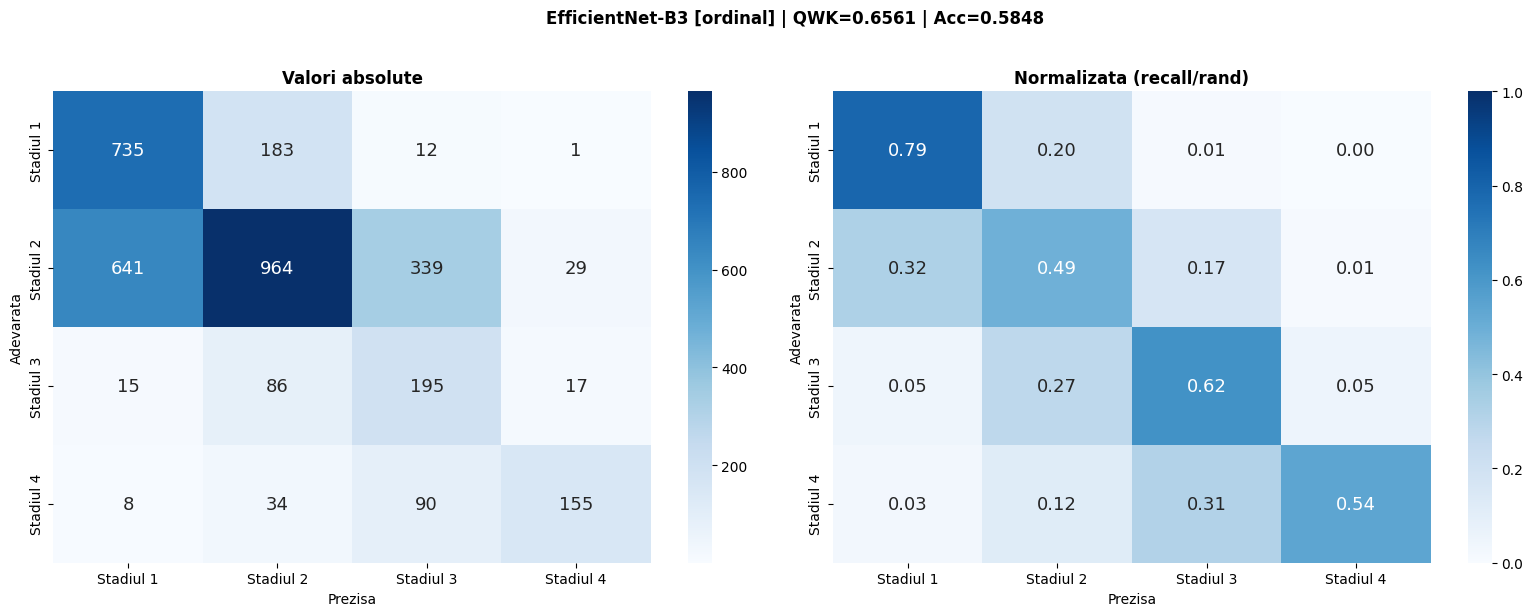


Distributia erorilor dupa distanta in grade:
  1 grad(e): 1356 (93.2% din erori)
  2 grad(e): 90 (6.2% din erori)
  3 grad(e): 9 (0.6% din erori)


In [23]:
model.load_state_dict(torch.load(CKPT)); model.eval()
print(f"=== EVALUARE PE TEST [{MODE}] ===")

# Pentru regresie: stringem scorurile continue ca sa fitam rounder-ul pe val
def collect(loader):
    preds, targets, scores = [], [], []
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="eval"):
            images = images.to(device)
            out = model(images)
            preds.extend(decode(out).cpu().tolist())
            targets.extend(labels.tolist())
            if MODE == "regression":
                scores.extend(raw_scores(out).cpu().numpy())
    return np.array(preds), np.array(targets), np.array(scores)

if MODE == "regression":
    _, val_t, val_s = collect(val_loader)
    rounder = OptimizedRounder(NUM_CLASSES); rounder.fit(val_s, val_t)
    print(f"Praguri optime (din val): {np.round(rounder.coef_, 3)}")
    _, test_t, test_s = collect(test_loader)
    test_p = rounder.predict(test_s)
else:
    test_p, test_t, _ = collect(test_loader)

test_acc = accuracy_score(test_t, test_p)
test_qwk = cohen_kappa_score(test_t, test_p, weights='quadratic')
print(f"\nTest Accuracy : {test_acc:.4f}")
print(f"Test QWK      : {test_qwk:.4f}\n")
print(classification_report(test_t, test_p, target_names=CLASS_NAMES, digits=3))

cm = confusion_matrix(test_t, test_p)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=axes[0], annot_kws={"size": 13})
axes[0].set_title('Valori absolute', fontweight='bold'); axes[0].set_ylabel('Adevarata'); axes[0].set_xlabel('Prezisa')
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=axes[1], annot_kws={"size": 13}, vmin=0, vmax=1)
axes[1].set_title('Normalizata (recall/rand)', fontweight='bold'); axes[1].set_ylabel('Adevarata'); axes[1].set_xlabel('Prezisa')
plt.suptitle(f'EfficientNet-B3 [{MODE}] | QWK={test_qwk:.4f} | Acc={test_acc:.4f}', fontweight='bold', y=1.02)
plt.tight_layout(); plt.savefig(f'matrice_confuzie_{MODE}.png', dpi=300, bbox_inches='tight'); plt.show()

# Erori adiacente vs. la distanta (relevant clinic + explica QWK)
err = test_p != test_t
if err.sum():
    d = np.abs(test_p[err] - test_t[err])
    print("\nDistributia erorilor dupa distanta in grade:")
    for k in sorted(np.unique(d)):
        c = (d == k).sum(); print(f"  {k} grad(e): {c} ({c/err.sum()*100:.1f}% din erori)")
